Exercice 1 : Comprendre le problème et collecter des données
Nous voulons prédire si une personne est atteinte de diabète.

Charge le jeu de données sur le diabète et explore-le.

Combien y a-t-il de cas positifs et négatifs ?

Divise les données en ensembles d’entraînement et de test.

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Chargement du fichier depuis ton dossier
df = pd.read_csv('Diabetes prediction dataset/diabetes_prediction_dataset.csv')

print("Aperçu des données :")
print(df.head())
print("\nInformations générales :")
print(df.info())

# 2. Comptage des cas positifs (1) et négatifs (0) avec le bon nom de colonne
print("\nRépartition des classes :")
print(df['diabetes'].value_counts())

# 3. Division en train/test (80% entraînement, 20% test)
X = df.drop(columns=['diabetes'])  # On supprime la colonne cible des caractéristiques
y = df['diabetes']                 # La colonne cible est 'diabetes'

# Comme la colonne 'gender' et 'smoking_history' contiennent du texte, 
# on applique un encodage rapide pour que les futurs modèles fonctionnent sans erreur
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTaille Train: {X_train.shape}, Taille Test: {X_test.shape}")

Aperçu des données :
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-n

Exercice 2 : Choix des modèles et normalisation

Quel modèle de classification pouvons-nous utiliser pour ce problème et pourquoi ?

Réponse : La régression logistique, parce que c'est un problème de classification binaire (le patient est soit diabétique, soit sain). C'est un modèle robuste, rapide et très facile à interpréter.

Faut-il standardiser les données ? Si oui, utilise StandardScaler().

Réponse : Oui, car les caractéristiques (comme l'âge, la glycémie blood_glucose_level ou l'IMC bmi) ont des échelles et des unités complètement différentes.

In [44]:
from sklearn.preprocessing import StandardScaler

# Initialisation du scaler et normalisation des données d'entraînement et de test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données standardisées avec succès.")

Données standardisées avec succès.


Exercice 3 : Entraînement de modèles

Nous allons utiliser le modèle de régression logistique. Entraîne-le.

In [45]:
from sklearn.linear_model import LogisticRegression

# Création et entraînement du modèle de régression logistique
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Modèle de régression logistique entraîné avec succès.")

Modèle de régression logistique entraîné avec succès.


Exercice 4 : Indicateurs d’évaluation

Calcule et affiche le score de précision (accuracy score), puis commente les résultats.

Affiche la matrice de confusion et commente les résultats.

Calcule le Rappel (Recall), la Précision et le F1-score, puis commente les résultats.

Accuracy Score: 0.9590


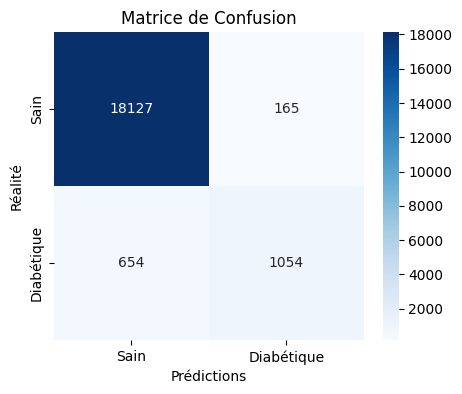


Rapport de classification complet :
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test_scaled)

# 1. Affichage de l'Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# 2. Affichage de la Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sain', 'Diabétique'], yticklabels=['Sain', 'Diabétique'])
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.show()

# 3. Rapport de classification (Precision, Recall, F1-score)
print("\nRapport de classification complet :")
print(classification_report(y_test, y_pred))

Exercice 5 : Visualisation de la performance du modèle

Visualise la frontière de décision (decision boundary) en y incluant les informations de précision.

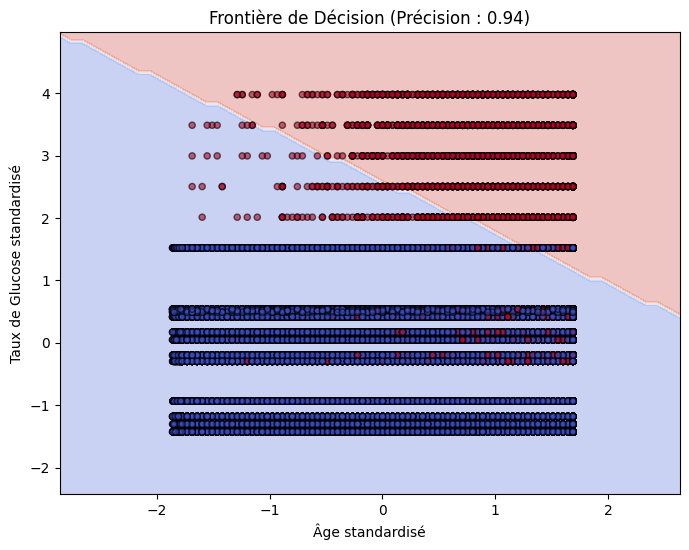

In [47]:
import numpy as np

# Pour pouvoir afficher une frontière en 2D, on sélectionne les deux colonnes numériques les plus importantes :
# L'âge (index 0) et le taux de glucose (index 5 après encodage)
X_visual = X_train_scaled[:, [0, 5]]
model_visual = LogisticRegression().fit(X_visual, y_train)

# Création de la grille pour dessiner la frontière
x_min, x_max = X_visual[:, 0].min() - 1, X_visual[:, 0].max() + 1
y_min, y_max = X_visual[:, 1].min() - 1, X_visual[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Prédiction sur chaque point de la grille
Z = model_visual.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Tracé de la frontière de décision
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_visual[:, 0], X_visual[:, 1], c=y_train, edgecolors='k', cmap='coolwarm', alpha=0.6, s=20)
plt.title(f"Frontière de Décision (Précision : {model_visual.score(X_visual, y_train):.2f})")
plt.xlabel('Âge standardisé')
plt.ylabel('Taux de Glucose standardisé')
plt.show()

Exercice 6 : Courbe ROC

Trace la courbe ROC.

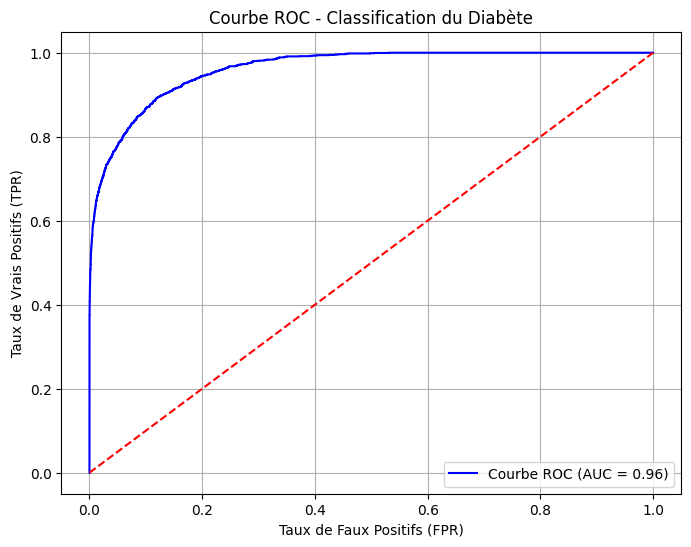

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calcul des probabilités de prédiction pour la classe positive
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Calcul du taux de faux positifs (fpr) et de vrais positifs (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Tracé graphique de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Courbe ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Classification du Diabète')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()